Same as `impact-maximisation-488-464_structure.ipynb`, but based on states instead of topology.

Note: the situation here is slightly different than in the purely structural case, because changing the states actually affects the neighbourhood density distribution. So there is some sort of feedback mechanism that makes re-distributing a bit more difficult. We over-simplify and assume that the initial state density distribution remains the same (which is the case in the thermodynamic limit, but then a tiny change of course also no longer matters).

I think this effect is visible in the decrease of the effect for large switch values.

In [1]:
# standard preamble for the Notebooks I use
import torch as tc
import igraph as ig
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import rcParams

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# compact saving of data
import h5py

from src.automata import LLNA
from src.simulation import *
from src.rules import binary_indices, return_equivalent_rule, get_nonequiv_rules, return_life_like_dict
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.analysis import median_and_percentiles_over_ensemble, mean_field_dens_propagation, derrida_map_analytical, hamming_weight, boolean_sens, mean_field_slope

%load_ext autoreload
%autoreload 2

This rule is equivalent to itself.


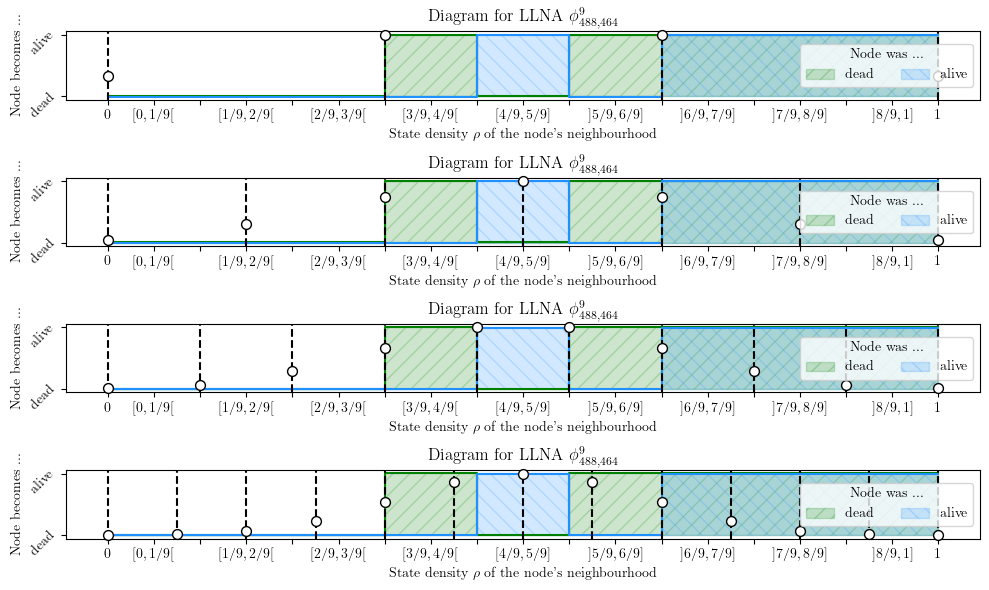

In [2]:
resolution = 9
beta, sigma = (488, 464)
B_set = binary_indices(beta)
S_set = binary_indices(sigma)

# this rule is equivalent to itself
beta_equiv, sigma_equiv = return_equivalent_rule(resolution, B_set, S_set, return_decimals=True)
if (beta, sigma) == (beta_equiv, sigma_equiv):
    print("This rule is equivalent to itself.")

model = LLNA(resolution, B_set, S_set, iso=True)

degrees = [3, 6, 9, 12]
fig, axs = plt.subplots(len(degrees),1,figsize=(10,1.5*len(degrees)))
for ax, degree in zip(axs, degrees):
    model.diagram(ax=ax, degree=degree, plot_dist=True)

fig.tight_layout()

Let us consider this update diagram from a configuration perspective instead of a purely structural one. We can make a couple of observations
1. If the neighbourhood is (near-)extinct, the outcome is always death. A living node that resides there, is destined to perish.
2. If the neighbourhood is very lively, the outcome is always life. A dead node that resides there, will certainly come to life.
3. Things get interesting in the middle, i.e. in $[3/9, 6/9]$
    - IS: when the state of the central node is toggled, the outcome in the next time step will also change. Example: the node has a nbh density $3/8$ and is alive itself. It was supposed to die in the next time step. Now you have toggled it to being dead (killer toggle), such that it now becomes alive in the next time step.
    - NS: when the neighbourhood is changed, the outcome is also likely to change

**Tactics**:

It is a bit difficult to predict what will happen in the chaos of the centre region. However, it _is_ easy to predict what happens at the density perifery. Therefore, this suggests two nodes that can be state-switched. Say we have two nodes:
1. One node is alive but has a very low neighbourhood density. In other words, it is destined to perish: it is already lost.
2. A second node is dead but is somewhere in the fuzzy middle region. It is therefore not clear what will happen to it after a few time steps, or what would happen to it if you toggle its state.

The states of these nodes can be switched, so you give the state that was bound to perish a "second chance".

# Introducing defects for tipping the scales

### First for a single initial configuration

In [3]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

def state_densities(adjacency_matrix, config):
    state_sums = np.matmul(adjacency_matrix, config)
    state_dens = state_sums / np.sum(adjacency_matrix, axis=0)
    return state_dens

(array([ 16., 114., 263., 527., 532., 527., 365., 130.,  26.]),
 array([0.        , 0.11111111, 0.22222222, 0.33333333, 0.44444444,
        0.55555556, 0.66666667, 0.77777778, 0.88888889, 1.        ]),
 <BarContainer object of 9 artists>)

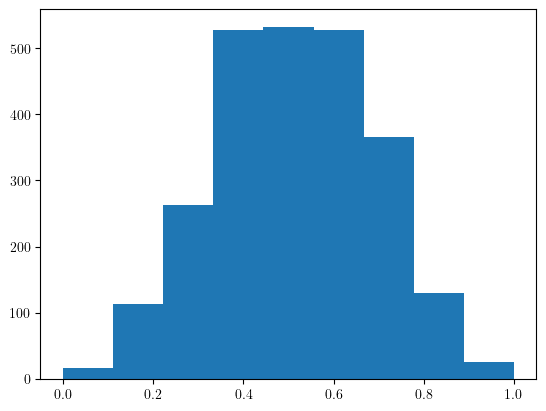

In [4]:
# Parameters
width = 50                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2     # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)

# find edges
small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

init_dens = 0.5
init_config = init_config_with_dens(num_nodes, init_dens)
init_config.shape

adjacency_matrix = np.array(small_world_graph.get_adjacency().data)
state_dens = state_densities(adjacency_matrix, init_config)

bins = np.linspace(0,1,10)
plt.hist(state_dens, bins=bins)

In [5]:
# quick check how many of the nodes are in the "safe zone"
turbulent_zone = (4/9, 5/9)
death_zone = (0, 1/3)
turbulent_zone_fraction = len(state_dens[(state_dens>=turbulent_zone[0]) & (state_dens<=turbulent_zone[1])]) / num_nodes
death_zone_fraction = len(state_dens[(state_dens>=death_zone[0])&(state_dens<death_zone[1])]) / num_nodes

print(f"Fraction of Turbulent Zone: {turbulent_zone_fraction}.")
print(f"Fraction of Death Zone: {death_zone_fraction}.")

Fraction of Turbulent Zone: 0.2596.
Fraction of Death Zone: 0.1572.


In [6]:
def switch_life_to_turbulent_zone(state_dens,
                                     init_config,
                                     number_of_switches,
                                     death_zone = (0, 1/3),
                                     turbulent_zone = (4/9, 5/9),
                                     kill_low_values=True):
    """
    Select living nodes that have a low neighbourhood state density (and are bound to die).
    Select dead nodes that are in the turbulent centre region (whose fate is uncertain).
    Kill the living node. Bring the dead node to life.
    
    Define the turbulent region ([4/9, 5/9] by default).
    Define the death zone ([0, 1/3[ by default).
    Start selecting with the 'most extinct' nodes in the dead zone (lowest nbh density in death zone),
    and with the 'most promising' nodes in the turbulent region (highest nbh density in turbulent zone).
    NOTE: the ideal values for the Death Zone and Turbulent Zone depend on the local update rule
    TODO: add values making sure that you do not switch more values than there are nodes that obey the conditions (alive and in death zone | dead and in turbulent zone)
    """
    if number_of_switches<0:
        raise ValueError(f"The number of switches must be a nutural number. Not {number_of_switches}.")
    if (number_of_switches > len(state_dens[state_dens<death_zone[1]])) or (number_of_switches > len(state_dens[(state_dens>=turbulent_zone[0])&(state_dens<=turbulent_zone[1])])):
        raise ValueError(f"The number of switches is more than the state density vector, death zone, and turbulent zone allow.")
    # get all values of this metric
    num_nodes = len(init_config)
    if len(state_dens) != num_nodes:
        raise ValueError(f"The number of nodes and the number of initial states do not match.")
    if number_of_switches > num_nodes//2:
        raise ValueError(f"You cannot switch places of more than half of the nodes.")
    default_value = 0
    if not kill_low_values:
        default_value = 1

    # get the indices of all nodes sorted by degree
    sorted_node_indices = np.argsort(state_dens)
    sorted_dens = state_dens[sorted_node_indices]
    # find unique values
    unique_dens = np.unique(state_dens)
    # if there not all values are unique, randomize the order within each subgroup with the same node property value
    if len(unique_dens) != num_nodes:
        # Randomize within groups (to avoid other correlations)
        shuffled_sorted_node_indices = np.empty_like(sorted_node_indices)
        start = 0
        for unique_d in unique_dens:
            # find where the indices correspond to the current node property value
            dens_indices = np.where(sorted_dens == unique_d)[0]
            # get the subarray of values coresponding to this value
            group = sorted_node_indices[dens_indices]
            # randomise the group
            np.random.shuffle(group)
            # glue the pieces back together
            shuffled_sorted_node_indices[start:start + len(group)] = group
            start += len(group)
        # order the initial configuration according to the shuffled dens-sorted indices
        init_config_shuffle_sorted = init_config[shuffled_sorted_node_indices]
        shuffled_sorted_dens = state_dens[shuffled_sorted_node_indices]
    else:
        shuffled_sorted_node_indices = sorted_node_indices
        init_config_shuffle_sorted = init_config[shuffled_sorted_node_indices]
        shuffled_sorted_dens = state_dens[shuffled_sorted_node_indices]
        
    # find the shuffled indices with low state density in the death zone, whose node is alive and kill 'em dead (by default). Start with the lowest values
    indices_where_alive = np.where(init_config_shuffle_sorted==1-default_value)[0]
    indices_in_death_zone = np.where((shuffled_sorted_dens>=death_zone[0]) & (shuffled_sorted_dens<death_zone[1]))
    indices_to_kill = np.intersect1d(indices_where_alive, indices_in_death_zone)[:number_of_switches]
    init_config_shuffle_sorted[indices_to_kill] = default_value
    # same for shuffled indices with high state density of dead nodes that are brought to life (by default). Start with the highest values.
    indices_where_dead  = np.where(init_config_shuffle_sorted==default_value)[0]
    indices_in_turbulent_zone = np.where((shuffled_sorted_dens>=turbulent_zone[0]) & (shuffled_sorted_dens<=turbulent_zone[1]))
    indices_to_spawn = np.intersect1d(indices_where_dead, indices_in_turbulent_zone)[-number_of_switches:] # indices_where_dead[(number_of_dead-number_of_switches):]
    init_config_shuffle_sorted[indices_to_spawn] = 1-default_value
    # undo the ordering
    init_config_switched = init_config_shuffle_sorted[np.argsort(shuffled_sorted_node_indices)]
    return init_config_switched

In [60]:
total=100
kill_low_values = False
death_zone = (3/9, 4/9)
turbulent_zone = (4/9, 5/9)

adjacency_matrix = np.array(small_world_graph.get_adjacency().data)
state_dens = state_densities(adjacency_matrix, init_config)

init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(total), total=total):
    init_config_switched = switch_life_to_turbulent_zone(state_dens, init_config,
                                                         number_of_switches,
                                                         death_zone=death_zone,
                                                         turbulent_zone=turbulent_zone,
                                                         kill_low_values=kill_low_values)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

100%|██████████| 100/100 [00:00<00:00, 414.24it/s]


If kill_low_values is True, you should see increasing white on the left (white is dead for cmap 'Greys')


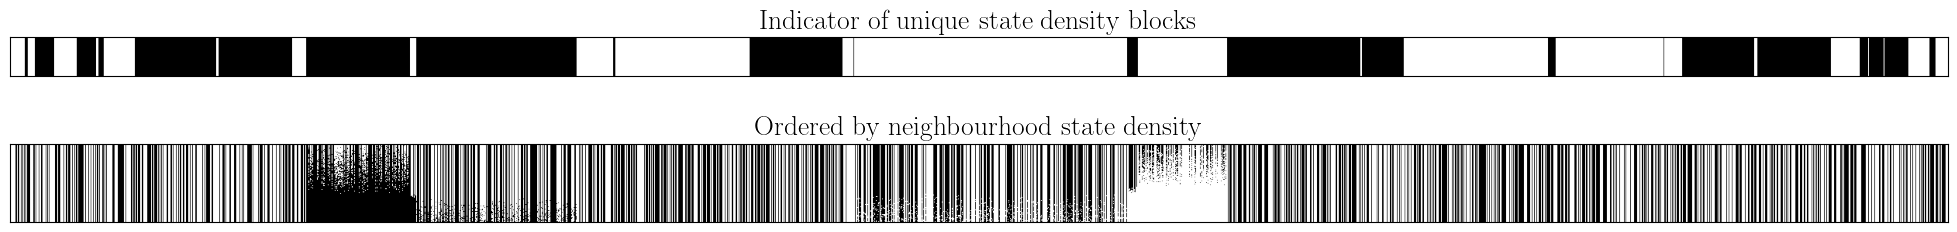

In [61]:
sorted_node_indices = np.argsort(state_dens)

_, unique_counts = np.unique(state_dens, return_counts=True)
indicator_list = []
for i, unique_count in enumerate(unique_counts):
    indicator_list += [i%2]*unique_count
indicator_array = np.array(indicator_list)
indicator_block = np.repeat(indicator_array[np.newaxis,:], repeats=50, axis=0)

fig, axs = plt.subplots(2,1,figsize=(25,3))

axs[0].imshow(indicator_block, cmap='Greys')
axs[1].imshow(init_config_stack[:,sorted_node_indices], cmap='Greys')
axs[0].set_title(f"Indicator of unique state density blocks", fontsize=20)
axs[1].set_title(f"Ordered by neighbourhood state density", fontsize=20)

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

print(f"If kill_low_values is True, you should see increasing white on the left (white is dead for cmap 'Greys')")

Text(0, 0.5, 'State density')

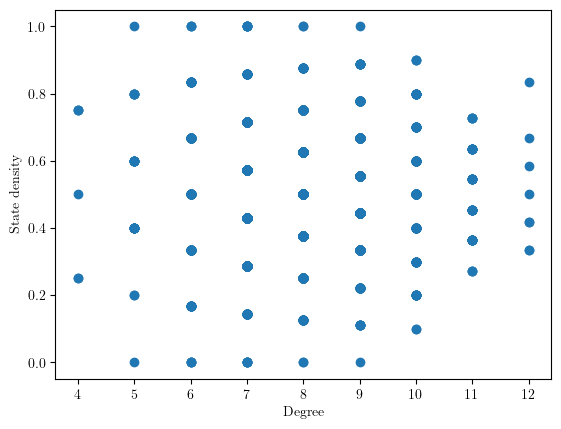

In [9]:
# very little correlation with the degree

plt.scatter(small_world_graph.degree(), state_dens)
plt.xlabel("Degree")
plt.ylabel(f"State density")

Now do run this for many more graphs, many more initial configurations, and many more structural node properties! And make sure to average over the switches (cause the order is chosen randomly as well). Also, make sure to compare to random switching.

### 1. Make many small-world graphs

In [62]:
# Parameters
width = 50                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
num_graphs = 30
rewiring_prob = 0.2         # Rewiring probability
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
# REWIRING CAN TAKE A WHILE!
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph_array = np.array([watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in tqdm(range(num_graphs), total=num_graphs)])

# find edges
small_world_edges_list = []
for small_world_graph in small_world_graph_array:
    small_world_graph.to_directed()
    small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges_list.append(small_world_edges)
    small_world_graph.to_undirected()
# small_world_edges_array = np.array(small_world_edges_list)

100%|██████████| 30/30 [01:11<00:00,  2.39s/it]


### 2. Make multiple runs on these graphs

In [63]:
def init_config_with_dens(N, dens):
    # defines a random initial configuration with a fixed state density
    s0 = np.zeros(N, dtype=int)
    s0[:np.round(dens*N).astype(int)] = 1.
    np.random.shuffle(s0)
    return s0

T = 100
num_config = 10
init_dens = 0.5

configs_list = []
for small_world_edges in tqdm(small_world_edges_list, total=num_graphs):
    # run the network automaton
    init_configs = np.array([init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)])
    configs = model.forward(small_world_edges, tc.tensor(init_configs), T=T).numpy().astype(int)
    # put back in L x L shape 
    configs = configs.reshape((num_config, T+1, width, width))
    configs_list.append(configs)
configs_array = np.array(configs_list)

100%|██████████| 30/30 [00:38<00:00,  1.27s/it]


In [64]:
# animations
import matplotlib.animation as animation
from IPython.display import HTML
from matplotlib import rcParams
rcParams['animation.embed_limit'] = 256  # MB. Set a higher limit for embedding animations

def make_animation_object(grids, title=None):
    # Set up figure
    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(grids[0])
    # Update function for animation
    def update(frame):
        im.set_array(grids[frame])
        ax.set_title(title, fontsize=20)
        ax.set_xticks([]); ax.set_yticks([])
        return [im]
    # Create animation
    ani = animation.FuncAnimation(fig, update, frames=T+1, interval=100)
    plt.close()
    return ani

In [65]:
ani = make_animation_object(configs_array[0,7], title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

### 3. Select all combinations (graph, init_config) that result in extinction

Observation: there is a natural spread over the graphs. The capacity of going extinct is not super dependent on the particular adjacency matrix.

In [66]:
extinction_automata_per_graph = []
for idx, small_world_graph in enumerate(small_world_graph_array):
    configs_per_graph = configs_array[idx]
    configs_mask = np.mean(configs_per_graph[:,-1], axis=(1,2))==0
    extinction_automata_per_graph.append(configs_per_graph[configs_mask])

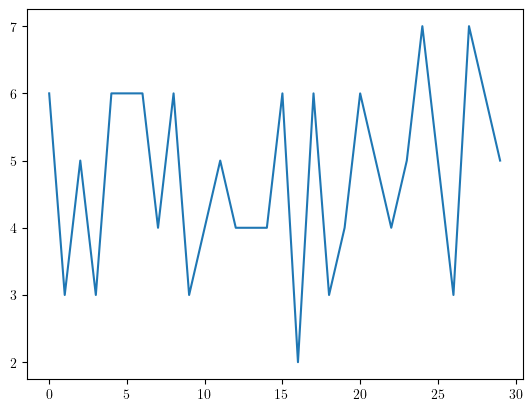

In [67]:
extinctions_per_graph = [extinction_automata_per_graph[idx].shape[0] for idx in range(num_graphs)]
plt.plot(extinctions_per_graph)

### 4. Run over all graphs and intial configurations that lead to extinction, and try to avoid extinction

Observation: a lot of systems will already flip their behaviour even after a single state switch!

Text(0.5, 0, 'State densities')

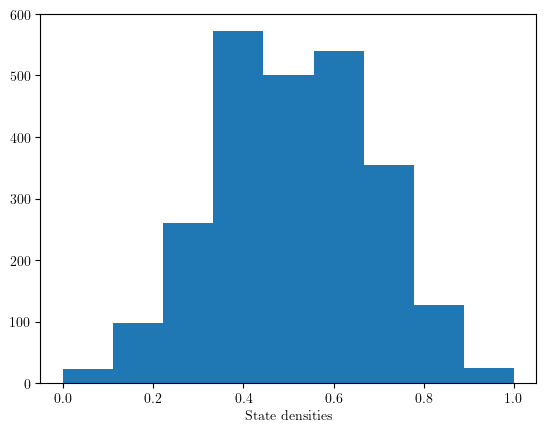

In [68]:
# np.array(np.random.choice(small_world_graph_array).eigenvector_centrality()) # np.random.permutation(num_nodes)
bins = np.linspace(0,1,10)
plt.hist(state_dens, bins=bins)
plt.xlabel(f"State densities")

In [69]:
# this creates a list for entries per graph.
# each entry has dimensions (max_switches, extinctions_per_graph, T+1, width, width)

#################################
# NOTE: change the value here!! #
#################################

death_zone = (3/9, 4/9)
turbulent_zone = (4/9, 5/9)
kill_low_values = True

max_switches = 100
configs_switched_list = []
for extinction_automata, small_world_graph, small_world_edges in tqdm(zip(extinction_automata_per_graph, small_world_graph_array, small_world_edges_list), total=num_graphs):
    extinctions_per_graph = extinction_automata.shape[0]
    ###############################################################
    adjacency_matrix = np.array(small_world_graph.get_adjacency().data)
    ###############################################################
    if extinctions_per_graph>0:
        init_configs = extinction_automata[:,0].reshape(extinctions_per_graph, width**2)
        init_configs_switched = []
        # also run over no-switch (makes life a little easier)
        for number_of_switches in range(0,max_switches+1):
            # add them together so we can use the parallellisation of the GNN
            for init_config in init_configs:
                state_dens = state_densities(adjacency_matrix, init_config)
                init_config_switched = switch_life_to_turbulent_zone(state_dens,
                                                                     init_config,
                                                                     number_of_switches,
                                                                     death_zone=death_zone,
                                                                     turbulent_zone=turbulent_zone,
                                                                     kill_low_values=kill_low_values)
                init_configs_switched.append(init_config_switched)
        init_configs_switched = np.array(init_configs_switched)
        configs_switched = model.forward(small_world_edges, tc.tensor(init_configs_switched), T=T).numpy().astype(int)
        configs_switched = configs_switched.reshape(max_switches+1, extinctions_per_graph, T+1, width, width)
        configs_switched_list.append(configs_switched)
    else:
        # There are no initial configurations that lead to extinction, so we skip this graph
        configs_switched_list = configs_switched_list + [None]

100%|██████████| 30/30 [14:22<00:00, 28.73s/it]


### 5. Show an example of a single switch that can change the entire outcome

In [70]:
graph_idx = 1
first_idx_with_extinction = 0
first_idx_with_full_population = 0
while True:
    config_with_extinction = configs_array[graph_idx,first_idx_with_extinction]
    if np.sum(config_with_extinction[-1])==0:
        config_switched_with_full_population = configs_switched_list[graph_idx][1,first_idx_with_full_population]
        if np.sum(config_switched_with_full_population[-1])==num_nodes:
            break
        first_idx_with_full_population += 1
    first_idx_with_extinction += 1

In [71]:
# original animation

ani = make_animation_object(config_with_extinction, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [55]:
# animation with tiny change

ani = make_animation_object(config_switched_with_full_population, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [72]:
# animation of the difference pattern

configs_defect = np.bitwise_xor(config_with_extinction, config_switched_with_full_population)

ani = make_animation_object(configs_defect, title=f"{model.__str__(latex=True)} on Small World graph")
# ani = make_animation_object(defects[example_idx])

# show inline
HTML(ani.to_jshtml())

In [66]:
# plt.plot(np.mean(configs_defect, axis=(1,2)))

By the way, I checked whether this is identical to running the defect as an initial condition. But that's certainly not the case. Clearly that could not be the case, cause the system will kill any seeds.

### 6. Make a scatter plot showing the average influence of switching states

In [73]:
print(f"Death zone: {death_zone}")
print(f"Turbulent zone: {turbulent_zone}")
SAVEDATA = False

if SAVEDATA:
    num_nodes = 2500
    degree = 8
    resolution = 9

    beta, sigma = (488, 464)
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    model = LLNA(resolution, B_set, S_set, iso=True)

    np.save(f"configs_array_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.npy", configs_array)
    with open(f"configs_switched_list_{node_property_name}_N{num_nodes}_{model.__str__()}_degree{degree}.pickle", 'wb') as handle:
        pickle.dump(configs_switched_list, handle, protocol=pickle.HIGHEST_PROTOCOL)

Death zone: (0.3333333333333333, 0.4444444444444444)
Turbulent zone: (0.4444444444444444, 0.5555555555555556)


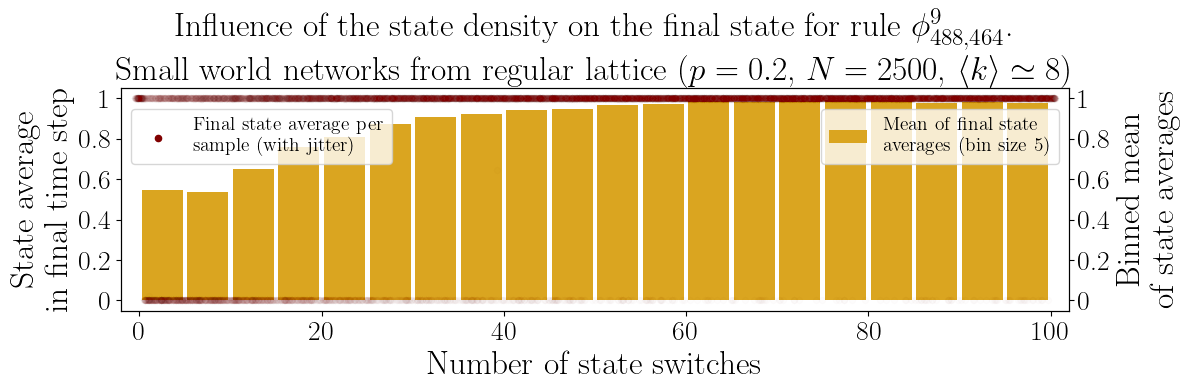

In [75]:
SAVEFIG=False

fig, ax1 = plt.subplots(1,1,figsize=(12,4))
fontsize=20
# Create the secondary y-axis
ax2 = ax1.twinx()

alpha=0.01

# open list where all y values are kept (which we will average over later)
y_vals_total = []
# loop over the 30 graphs
for i, configs_switched in enumerate(configs_switched_list):
    if configs_switched is not None:
        # loop over the initial conditions that led to extinction
        number_of_extinctions = configs_switched.shape[1]
        for sample_idx in range(number_of_extinctions):
            hjitter = np.random.random(max_switches+1)-0.5
            x_vals = np.arange(max_switches+1)+hjitter
            y_vals = np.mean(configs_switched[:,sample_idx,-1], axis=(1,2))
            y_vals_total.append(y_vals)
            label=None
            if i==0 and sample_idx==0:
                label='Final state average per\nsample (with jitter)'
            ax1.scatter(x_vals, y_vals, color='maroon', alpha=alpha, s=20, label=label, zorder=10)

# Average over all samples
y_vals_avg = np.mean(y_vals_total, axis=0)  # shape: (max_switches + 1,)

# Bin into intervals of 5
bin_width = 5
bins = np.arange(0, max_switches + 2, bin_width)  # +2 to include max_switches
bin_centers = (bins[:-1] + bins[1:]) / 2

binned_means = []
for i in range(len(bins) - 1):
    start, end = bins[i], bins[i+1]
    bin_avg = np.mean(y_vals_avg[start:end])
    binned_means.append(bin_avg)

# Overlay bar chart
ax2.bar(bin_centers, binned_means, width=bin_width*0.9, color='goldenrod', alpha=1, zorder=0, label=f'Mean of final state\naverages (bin size ${bin_width}$)')

# make axis pretty
ax1.set_ylim(-0.05, 1.05)
ax2.set_ylim(-0.05, 1.05)
ax1.set_xlim(-2, 102)
xticks = [0, 20, 40, 60, 80, 100]
yticks = [0, .2, .4, .6, .8, 1]
ax1.set_xticks(xticks)
ax1.set_xticklabels(xticks, fontsize=fontsize)
ax1.set_yticks(yticks)
ax2.set_yticks(yticks)
ax1.set_yticklabels(yticks, fontsize=fontsize)
ax2.set_yticklabels(yticks, fontsize=fontsize)
ax1.set_xlabel("Number of state switches", fontsize=fontsize+4)
ax1.set_ylabel(f"State average\nin final time step", fontsize=fontsize+4)
ax2.set_ylabel(f"Binned mean\nof state averages", fontsize=fontsize+4)

legend = ax1.legend(loc='upper left', bbox_to_anchor=(0,.95), fontsize=fontsize-6)
for handle in legend.legend_handles:
    handle.set_alpha(1)
# ax2.legend(loc='lower right', bbox_to_anchor=(1,0.05), fontsize=fontsize-6)
ax2.legend(loc='upper right', bbox_to_anchor=(1,0.95), fontsize=fontsize-6)

# make sure the scatter plot is in front of the bar plot
ax1.set_zorder(2)
ax2.set_zorder(1)
ax1.patch.set_visible(False)  # This is critical!

# set a title
ax1.set_title(f"Influence of the state density on the final state for rule {model.__str__(latex=True)}.\nSmall world networks from regular lattice ($p=0.2$, $N={num_nodes}$, $\\langle k \\rangle \\simeq 8$)", fontsize=fontsize+4)

fig.tight_layout()

if SAVEFIG:
    plt.savefig(f"influence-of-state-density-switch-from-(3to9,4to9)-to-(4to9,5to9)-on-outcome.pdf")

The strongest effect is found when moving from death zone $[3/9, 4/9[$ to turbulent zone $[4/9, 5/9]$. This is the strongest effect that I have seen so far (much stronger than e.g. degree-based). Strangely, this is even stronger than moving those from the place where they're destined to die anyway. That's a bit counterintuitive.

Inversely, if you want to make sure that the network goes extinct, you can move all living cells from the turbulent zone $[4/9,5/9]$ to the death zone, where they will immediately go to waste.

# Blinking of communicator nodes

In [42]:
def count_bit_switches(bit_array):
    """
    Counts the number of times a bit switches from 0 to 1 or 1 to 0 in a given array.

    Parameters:
        bit_array (numpy.ndarray): A 1D array of bits (0s and 1s).

    Returns:
        int: The number of bit switches.
    """
    if len(bit_array) < 2:
        return 0  # No switches possible in an array with fewer than 2 elements

    # Calculate the difference between consecutive elements
    switches = np.sum(bit_array[:-1] != bit_array[1:])
    return switches

count_bit_switches(configs_array[0,0,:,0,0])

18